# Handling Missing Values

#### Missing values can severely affect model performance and analysis, so handling them properly is a key step in data preprocessing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [48]:
df = pd.read_csv('train.csv')

In [49]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Common Techniques to Handle Missing Values

In [5]:
# 1 -- CCA - Complete case analysis
# Removing missing values - entire row

In [6]:
# complete case analysis

# Complete Case Analysis

complete case analysis (CCA), also called "list-wise deletion" of cases, consists in discarding observations where values in any of the variables are missing.

Complete case analysis means literally analyzing only those observations for which there is information in all of the variables in the dataset


In [7]:
# Assumption for CCA

Missing completely at random (MCAR)

### Advantage
1. Easy to implement as no data manipulation required.
2. Preserves variable distribution (if data is MCAR, then the distribution of the variable of the reduced dataset should match the distribution in the original dataset

### Disadvantage
1. It can exclude a large fraction of the original dataset (if missing data is abundant)
2. Excluded observations could be informative for the analysis if data is not missing at random
3. When using our models in production, the model will not know how to handle missing data

### When to use CCA
1. MCAR
2. less than 5%

In [5]:
df = df.dropna(subset=['Age'])

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64

# Handling Missing Numerical Data

Univariate Imputation
1. mean/median Imputation

Easy to use 

generally for less then 5-10% data

Disadvantage - 
1. Changes the distribution
2. outliers
3. covariance/correlation

### When to use

1. MCAR
2. less than 5%

In [7]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [50]:
new_df = df.drop(columns=['Name','Sex','Ticket','Cabin','Embarked','PassengerId'],axis=1)

In [51]:
new_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [52]:
x = new_df.drop('Survived',axis=1)
y = new_df['Survived']

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [45]:
from sklearn.impute import SimpleImputer

In [14]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [15]:
imputer1.fit(x_train)

SimpleImputer(strategy='median')

In [17]:
x_train_imputed = imputer1.transform(x_train)
x_test_imputed = imputer1.transform(x_test)

In [18]:
x_train_imputed = pd.DataFrame(x_train_imputed,columns=x_train.columns)

In [19]:
imputer1.statistics_

array([ 2.  , 28.5 ,  0.  ,  0.  , 15.75])

# Arbitrary Value Imputation

In [22]:
# any arbitrary value == -1


# advantage - simple
# disadvantage - Distribution change

In [23]:
# df['age'].fillna(99)
# df['age'].fillna(999)

In [20]:
from sklearn.impute import SimpleImputer

In [46]:
model = SimpleImputer(strategy='constant',fill_value=99)

In [28]:
# data is not missing at random
# but not used very often

In [29]:
df['Age'].isnull().sum()

177

In [47]:
model.fit(x_train)

SimpleImputer(fill_value=99, strategy='constant')

# End of Distribution Imputation

In [29]:
# incase of Normal distribution -- mean + 3sigma
# iqr proximity rule -- q1- 1.5*IQR
# --- q3 - 1.5 IQR


In [30]:
# data is not missing at random

# Random Imputation

In [31]:
# random from the same column
# it can be applied to both numerical and categorical columns
# easy to use --- we don't have any class in sklearn for this

# distribution and variance will almost remain same

In [32]:
# memory heavy for deployment as we need to store the original training set to extract values from and replace the NA in coming observations

In [56]:
x_train

,Pclass,Age,SibSp,Parch,Fare
331,1,45.5,0,0,28.5000
733,2,23.0,0,0,13.0000
382,3,32.0,0,0,7.9250
704,3,26.0,1,0,7.8542
813,3,6.0,4,2,31.2750
...,...,...,...,...,...
106,3,21.0,0,0,7.6500
270,1,NaN,0,0,31.0000
860,3,41.0,2,0,14.1083
435,1,14.0,1,2,120.0000


In [57]:
new = x_train.copy()

In [59]:
new['Age'].isnull().sum()

140

In [60]:
new['age_imputed'] = new['Age']

In [61]:
new.head()

,Pclass,Age,SibSp,Parch,Fare,age_imputed
331,1,45.5,0,0,28.5000,45.5
733,2,23.0,0,0,13.0000,23.0
382,3,32.0,0,0,7.9250,32.0
704,3,26.0,1,0,7.8542,26.0
813,3,6.0,4,2,31.2750,6.0


In [62]:
new_test = x_test.copy()

In [63]:
new_test['age_imputed'] = new_test['Age']

In [64]:
# new['age_imputed'][new['age_imputed'].isnull()] = new['Age'].dropna().sample(new['Age'].isnull().sum()).values

In [70]:
new['Age'].dropna().sample(new['Age'].isnull().sum()).values

array([ 4.  , 21.  , 19.  , 33.  ,  1.  , 51.  , 39.  , 37.  , 22.  ,
       35.  , 28.  , 49.  , 30.  , 34.  , 15.  , 23.  , 29.  , 60.  ,
       30.  , 44.  , 36.  , 30.  , 39.  , 50.  , 62.  , 46.  , 40.  ,
        2.  ,  4.  , 52.  , 45.5 , 48.  , 59.  , 34.  , 31.  , 23.  ,
       29.  , 23.  , 28.  , 23.  , 13.  , 20.  , 16.  , 25.  , 62.  ,
       39.  , 47.  , 23.  , 49.  , 21.  , 51.  , 25.  , 44.  , 23.  ,
       36.  , 21.  , 33.  , 56.  , 16.  , 29.  , 43.  , 34.  , 19.  ,
       27.  , 24.  , 25.  ,  9.  , 23.  ,  8.  , 17.  , 22.  , 25.  ,
       33.  , 24.  , 35.  , 28.  , 38.  ,  4.  ,  2.  , 43.  , 32.  ,
        4.  , 52.  , 22.  , 34.  ,  2.  , 14.  , 38.  , 18.  , 30.  ,
       51.  , 38.  , 41.  , 35.  , 48.  , 54.  , 27.  , 26.  , 25.  ,
        0.75, 53.  , 24.  , 28.  , 56.  , 19.  ,  6.  , 33.  , 11.  ,
       35.  ,  3.  , 25.  , 50.  , 21.  , 61.  , 45.  ,  7.  , 26.  ,
       20.  , 22.  , 41.  , 40.  , 44.  , 31.  , 17.  , 25.  , 35.  ,
       30.  , 18.  ,

In [71]:
new['age_imputed'][new['age_imputed'].isnull()] = new['Age'].dropna().sample(new['Age'].isnull().sum()).values

C:\Users\Datamites\AppData\Local\Temp\ipykernel_4284\754103505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['age_imputed'][new['age_imputed'].isnull()] = new['Age'].dropna().sample(new['Age'].isnull().sum()).values


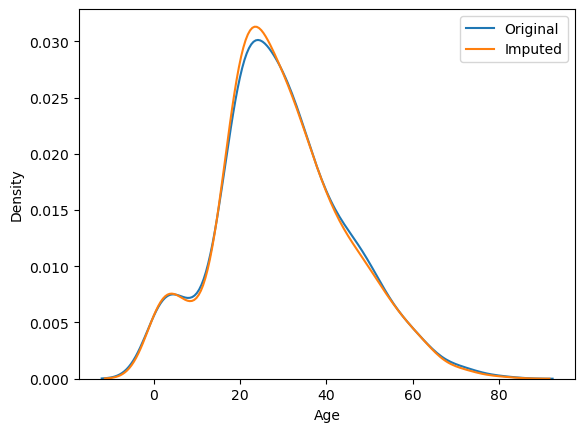

In [63]:
sns.kdeplot(x_train['Age'],label='Original')
sns.kdeplot(new['age_imputed'],label='Imputed')
plt.legend()

In [64]:
print('Original Variable Variance :- ', x_train['Age'].var())
print('Variance after random imputation :- ', new['age_imputed'].var())

Original Variable Variance :-  217.14409411586857
Variance after random imputation :-  211.24444024603287


# Missing Indicator

In [65]:
# we create new column correspnding to the column having missing values 
# -- we indicate true false in that new column

In [66]:
# missing indicator

In [67]:
from sklearn.impute import MissingIndicator

In [68]:
mi = MissingIndicator()

In [69]:
mi.fit(x_train)

MissingIndicator()

In [70]:
mi.features_

array([1], dtype=int64)

In [71]:
x_train_missing = mi.transform(x_train)

In [72]:
x_train_missing

array([[False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [

In [73]:
x_test_missing = mi.transform(x_test)

In [74]:
new2 = x_train.copy()

In [75]:
new2_test = x_test.copy()

In [76]:
new2['Age_NA'] = x_train_missing

In [77]:
new2_test['Age_NA'] = x_test_missing

In [78]:
new2.head()

,Pclass,Age,SibSp,Parch,Fare,Age_NA
708,1,22.0,0,0,151.5500,False
240,3,NaN,1,0,14.4542,True
382,3,32.0,0,0,7.9250,False
792,3,NaN,8,2,69.5500,True
683,3,14.0,5,2,46.9000,False


In [79]:
# add_indicator=True

In [80]:
# 



In [81]:
missing_imputer = SimpleImputer(add_indicator=True)

In [83]:
missing_imputer.fit(x_train)

SimpleImputer(add_indicator=True)

In [87]:
xx = missing_imputer.transform(x_train)

In [88]:
yy = missing_imputer.transform(x_test)

In [92]:
newdf = pd.DataFrame(xx,columns=list(x_train.columns) + ['Imputed'])

In [93]:
newdf

,Pclass,Age,SibSp,Parch,Fare,Imputed
0,1.0,22.000000,0.0,0.0,151.5500,0.0
1,3.0,29.905745,1.0,0.0,14.4542,1.0
2,3.0,32.000000,0.0,0.0,7.9250,0.0
3,3.0,29.905745,8.0,2.0,69.5500,1.0
4,3.0,14.000000,5.0,2.0,46.9000,0.0
...,...,...,...,...,...,...
706,3.0,29.905745,0.0,0.0,7.7750,1.0
707,3.0,25.000000,0.0,0.0,0.0000,0.0
708,1.0,48.000000,0.0,0.0,25.9292,0.0
709,3.0,21.000000,2.0,2.0,34.3750,0.0
